### 0. Importing PyTorch and setting device-agnostic code 

In [49]:
import torch
from torch import nn

In [50]:
# Setup device-agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### 1. Get data

In [51]:
from pathlib import Path

In [52]:
data_dir = Path("chest_xray")

In [53]:
train_dir = data_dir / "train"
test_dir = data_dir / "test"
val_dir = data_dir / "val"

print(train_dir)
print(test_dir)
print(val_dir)

chest_xray\train
chest_xray\test
chest_xray\val


### 1.1 Visualizing an image

1. Get all of the image paths
2. Pick a random image using Python's random.choice()
3. Get image class using pathlib.Path.parent.stem
4. Since, I am working with images, let's open the image with Python's PIL
5. I'll then show the image and print metadata

In [54]:
import random
from PIL import Image

Image class: PNEUMONIA
Image height: 840
Image width: 1056


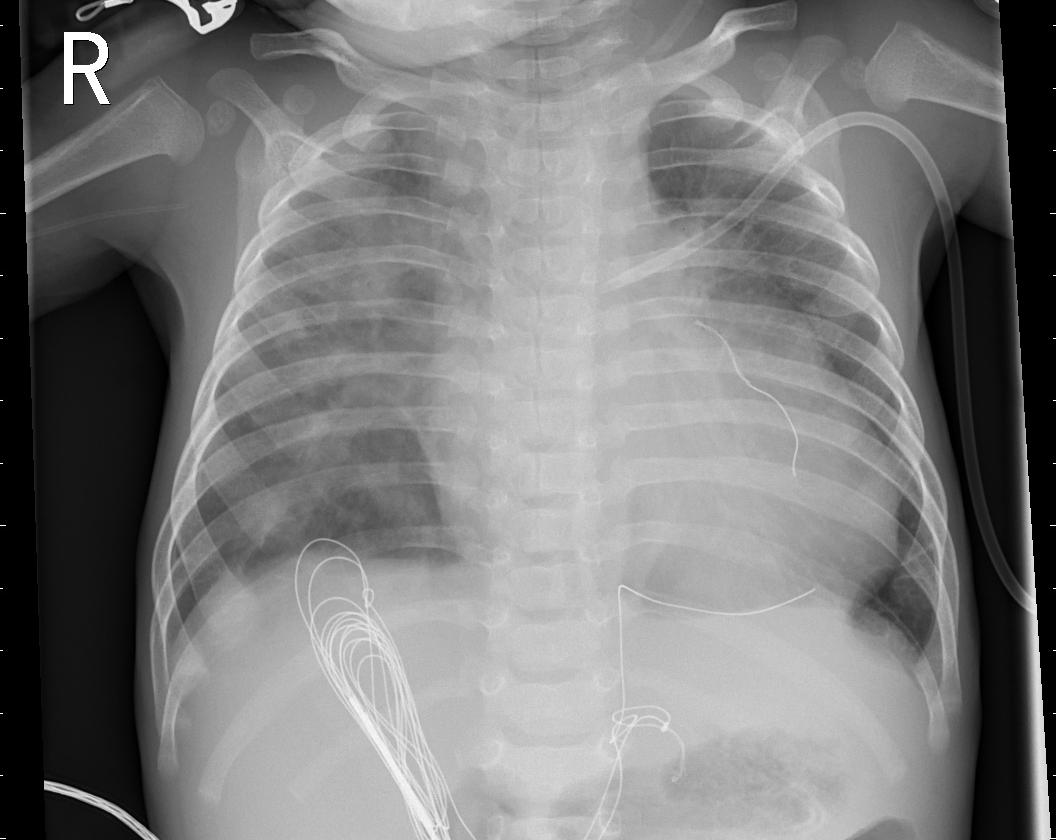

In [55]:
# 1. Getting all the image path 
image_path_list = list(data_dir.glob("*/*/*.jpeg"))
image_path_list

# 2. Pick a random image
random_image_path = random.choice(image_path_list)

# 3. Get the image class from path name(the image class is the name of the directory where the the image is saved)
image_class = random_image_path.parent.stem

# 4. Open the image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

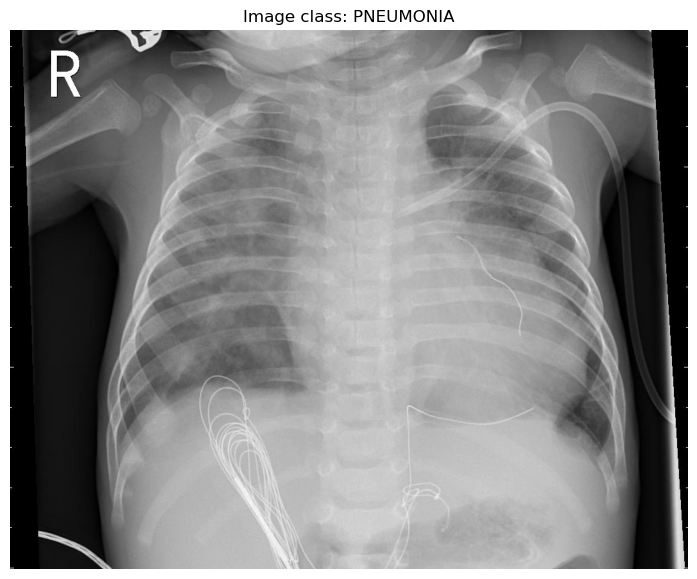

In [56]:
# Visualize with matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Truning image into nparray
img_as_array = np.array(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array, cmap= "gray")
plt.title(f"Image class: {image_class}")
plt.axis(False)
plt.show()


### 2. Making data ready

#### 2.1 Cheking the train and validation split

In [57]:
for split in [train_dir, test_dir, val_dir]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = split / cls
        n = len(list(folder.glob("*.jpeg")))
        print(split.name, cls, n)

train NORMAL 1341
train PNEUMONIA 3875
test NORMAL 234
test PNEUMONIA 390
val NORMAL 8
val PNEUMONIA 8


#### 2.2 Creating new train and validation split (85% and 15%)

In [58]:
import shutil
import random

random.seed(42)

new_val_dir = Path("chest_xray/new_val")
new_train_dir = Path("chest_xray/new_train")

val_fraction = 0.15 # train and validation split is 85 - 15

for cls in ["NORMAL", "PNEUMONIA"]:
    src_folder = train_dir / cls
    images = list(src_folder.glob("*.jpeg"))
    random.shuffle(images)

    n_val = int(len(images) * val_fraction)
    val_images = images[:n_val]
    train_images = images[n_val:]

    (new_val_dir / cls).mkdir(parents=True, exist_ok=True)
    (new_train_dir / cls).mkdir(parents=True, exist_ok=True)

    for img in val_images:
        shutil.copy(img, new_val_dir / cls / img.name)
    for img in train_images:
        shutil.copy(img, new_train_dir / cls / img.name)

    print(cls, "train:", len(train_images), "val:", len(val_images))

NORMAL train: 1140 val: 201
PNEUMONIA train: 3294 val: 581


### 3. Transforming data

Before I can use our image data with PyTorch:

    1. I need to turn my data into tensors.
    2. Turn into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`. 

In [59]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### 3.1 Transforming data with `torchvision.transfor`

In [60]:
# transform for images
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size = (64,64)),
    transforms.ToTensor()
])

#### 3.2 plotting different images after transform

In [61]:
def plot_transformed_images(image_path: list, transform, n= 3):
    """
    Selects random images from a path of images and transforms them
    then plots the original vs transformed version.
    """
    random_image_path = random.sample(image_path, k = n)
    for image_path in random_image_path:
        with Image.open(image_path) as f:
            # Plotting Original Images
            fig, ax = plt.subplots(nrows = 1, ncols = 2)
            ax[0].imshow(f, cmap = "gray")
            ax[0].set_title(f"Originl\nSize: {f.size}")
            ax[0].axis(False)

            # Plotting Main Images
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image, cmap = "gray")
            ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize = 16)



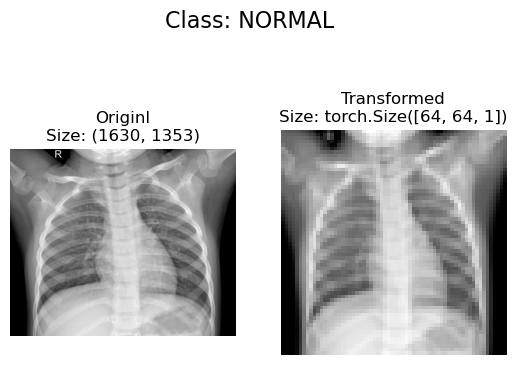

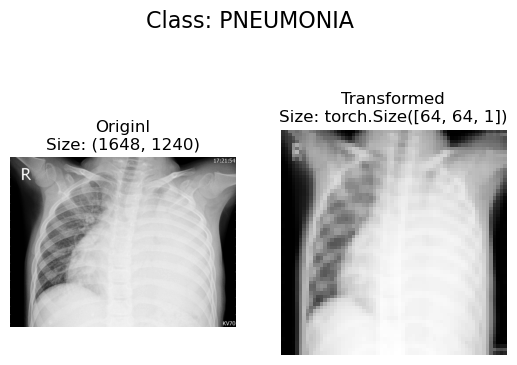

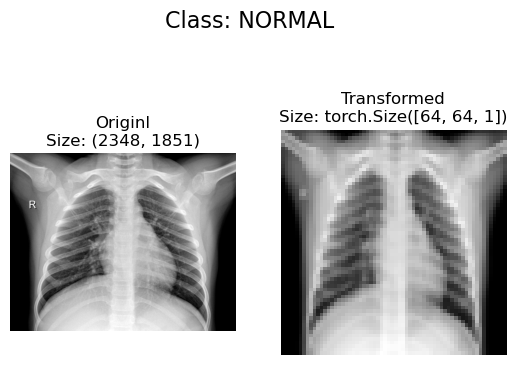

In [62]:
plot_transformed_images(image_path= image_path_list,
                        transform= data_transform,
                        n = 3)

### 4. Loading images using `ImageFolder`

I will be loading the image classification data using `torchvision.datasets.ImageFolder`

In [63]:
from torchvision import datasets
train_data = datasets.ImageFolder(root= new_train_dir,
                                  transform= data_transform,
                                  target_transform= None)
validation_data = datasets.ImageFolder(root = new_val_dir,
                                       transform= data_transform,
                                       target_transform= None)

test_data = datasets.ImageFolder(root = test_dir,
                                 transform= data_transform)

In [64]:
train_data, test_data, validation_data

(Dataset ImageFolder
     Number of datapoints: 4434
     Root location: chest_xray\new_train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 624
     Root location: chest_xray\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 782
     Root location: chest_xray\new_val
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [48]:
# Get the class names 
class_names = train_data.classes
class_names

['NORMAL', 'PNEUMONIA']

In [65]:
# Get the class names as dict
class_dict = train_data.class_to_idx
class_dict

{'NORMAL': 0, 'PNEUMONIA': 1}

In [66]:
# checking the length of train and validation 
len(train_data), len(validation_data)

(4434, 782)

#### 4.1 Turning my loaded images into `DataLoader`s

A DataLoader is going to help my dataset into iterables and we can customise the `batch_size` so my model can see the `batch_size` images at a time.

In [67]:
import os 


In [68]:
# Turn train and test datasets into DataLoader'
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKER = os.cpu_count()

train_dataloader = DataLoader(dataset= train_data,
                              batch_size= BATCH_SIZE,
                              num_workers= NUM_WORKER,
                              shuffle= True)
validation_dataloader = DataLoader(dataset= validation_data,
                                   batch_size= BATCH_SIZE,
                                   num_workers= NUM_WORKER,
                                   shuffle= False)
test_dataloader = DataLoader(dataset= test_data,
                             batch_size= BATCH_SIZE,
                             num_workers= NUM_WORKER,
                             shuffle= False)

In [69]:
len(train_dataloader), len(validation_dataloader), len(test_dataloader)

(139, 25, 20)

In [70]:
img , label = next(iter(train_dataloader))
print(f"Image shape: {img.shape}")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])
